# nb36 — renko invalidation + liquidity-sweep stop-orders

The existing FVG-inversion rule (the 1s-close pierce in
`detect_fvg`) is noisy on 1s XAUUSD — a single wick past the zone
flips polarity even when the market hasn't actually committed to
the other side. The classic "retail SL hunt" pattern is:
**price sweeps THROUGH an FVG zone, then reverses back THROUGH the
zone in the original direction.** The existing soft-stop logic
kills our open FVG trades at the WORST price in the move (the sweep
bar's close). We can't always avoid the SL, but we CAN place a
stop-order past the zone edge BEFORE the sweep happens so when the
sweep fires, we enter at the worst price, then ride the reversal.

This notebook layers three new behaviours on top of the existing
3-layer FVG / iFVG / soft-stop stack:

1. **Renko brick staircase** — a structural, time-decoupled
   "the market has committed to the OTHER side" signal. When the
   renko brick direction opposes the FVG direction AND the renko
   close has been on the wrong side of the zone edge for
   ≥ `renko_invalidation_min_bricks` consecutive bricks, the
   bar-loop sets the soft-stop. The renko state is also drawn on
   the chart as a brick staircase so the user can see WHY a zone
   was invalidated.

2. **Liquidity-sweep stop-order** — a stop order placed past each
   live FVG zone's edge. When price sweeps THROUGH the zone
   (retail SL hunt), the stop fills and we ride the reversal back.
   The classic ICT pattern: a long FVG forms, price sweeps below
   (taking out retail longs' SL), then price comes back to validate
   the FVG and shoots up. The sweep signal is the systematic way
   to profit from this pattern.

3. **Structure-driven FVG invalidation** — BoS / CHoCH events in
   the OPPOSING direction of an FVG's thesis kill the zone (turn
   it into an iFVG) WITHOUT requiring a price-side pierce. A bear
   BoS / bear CHoCH kills bull FVGs (the structural thesis has
   been rejected — the trend has flipped); a bull BoS / bull CHoCH
   kills bear FVGs. The rule fires forward in time from each
   zone's trigger_bar so there's no look-ahead. Structure breaks
   are drawn on the chart as labeled vertical arrows so the user
   can see exactly which event killed which zone.

The chart overlays:
* FVG zones (cyan / magenta, like nb34)
* Mitigation markers + trade entries/exits (like nb34)
* Renko bricks (right-side y-margin; small rectangle per brick
  colored by direction — green for up-bricks, red for down-bricks)
* Sweep stop-order entries (gold diamond at the sweep_price bar,
  with a dashed line connecting the parent zone to the fill)
* Structure breaks (vertical dashed arrows with direction labels)

## Knobs

The `VIZ_*` constants at the top of cell 4 are the only knobs.
Edit and re-run to refresh the chart.


## Imports + 1-day sample

In [1]:
import os, sys
os.environ.setdefault('MPLBACKEND', 'Agg')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path


def _find_root() -> Path:
    here = Path('.').resolve()
    candidates = [p for p in [here, *here.parents]
                  if (p / 'src' / 'core' / 'ict_signals.py').is_file()]
    if not candidates:
        raise RuntimeError('Could not find ICT repo root (no src/core/ict_signals.py)')
    def _has_fork_sig(p: Path) -> bool:
        f = p / 'src' / 'core' / 'ict_strategy.py'
        try:
            return 'renko_drive_invalidation' in f.read_text(encoding='utf-8')
        except OSError:
            return False
    with_sig = [p for p in candidates if _has_fork_sig(p)]
    return with_sig[0] if with_sig else candidates[0]


ROOT = _find_root()
sys.path.insert(0, str(ROOT))

from src.core import TrendStrategyParams
from src.core.ict_signals import (
    detect_fvg, compute_renko_bars,
)
from src.core.market_structure import detect_market_structure, StructureEvent
from src.backtest import run_ict_backtest

print('Imports OK')
print('Project root:', ROOT)


Imports OK
Project root: C:\coding\gmma_guppy_ict


In [2]:
# Load a 1-day sample with active FVG + sweep activity.
import pyarrow.dataset as ds
data_dir = ROOT / 'data'
if not (data_dir / 'XAUUSD_S1_1y.parquet').exists():
    for ancestor in [ROOT.parent, *ROOT.parent.parents]:
        sibling = ancestor / 'data'
        if (sibling / 'XAUUSD_S1_1y.parquet').exists():
            data_dir = sibling
            break

VIZ_DATE = '2025-01-08'
viz_start = pd.Timestamp(VIZ_DATE, tz='UTC')
viz_end = viz_start + pd.Timedelta(days=2)
parquet_path = data_dir / 'XAUUSD_S1_1y.parquet'
dataset = ds.dataset(str(parquet_path), format='parquet')
table = dataset.to_table(
    columns=['time', 'open', 'high', 'low', 'close', 'tickv'],
    filter=(ds.field('time') >= viz_start) & (ds.field('time') < viz_end),
)
df = table.to_pandas()
df = df.rename(columns={'tickv': 'volume'})
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)
print(f'Data dir: {data_dir}')
print(f'Viz day: {len(df):,} bars  ({df.time.iloc[0]} -> {df.time.iloc[-1]})')


Data dir: C:\coding\gmma_guppy_ict\data
Viz day: 119,697 bars  (2025-01-08 00:00:00+00:00 -> 2025-01-09 23:59:59+00:00)


## Run the backtest with renko + sweep ON

In [3]:
p = TrendStrategyParams(
    signal_source='fvg',
    additional_sources=['ifvg', 'sweep'],
    fvg_resample_secs=60,
    fvg_min_zone_usd=0.30,
    num_layers=3,
    inverse_breadth=True,
    invalidation_sl_usd=0.05,
    invalidation_buffer_usd=0.02,
    use_market_structure=True,
    ms_min_conviction=0.0,
    ms_boost_conviction=1.5,
    use_atr_scaling=True,
    atr_len=1200,
    sl_atr_mult=0.25, tp_atr_mult=0.55,
    sl_usd=0.80, tp_usd=1.80, lots=0.01,
    # NEW (2026-09-05)
    renko_drive_invalidation=True,
    renko_brick_size_usd=0.30,
    renko_invalidation_min_bricks=2,
    renko_invalidation_buffer_usd=0.05,
    fvg_sweep_enabled=True,
    fvg_sweep_distance_usd=0.10,
    fvg_sweep_min_zone_usd=0.20,
    fvg_sweep_max_age_secs=1800,
    fvg_sweep_atr_mult=0.5,
    # NEW (2026-09-05): BoS/CHoCH gate FVGs by direction.
    # A bear BoS/CHoCH kills bull FVGs; a bull BoS/CHoCH kills bear FVGs.
    # Default age cap of 30s: only FRESH FVGs (≤ 30s old) are killed
    # by an opposing structure event. Rationale: the XAUUSD 1s market
    # is structurally noisy — structure events flip rapidly through
    # the day. A 5-min age cap kills most FVGs because there's almost
    # always an opposing event within 5 minutes; a 30s cap kills only
    # very fresh FVGs that haven't had time to fill. Tune this knob
    # for your instrument's volatility regime.
    fvg_invalidate_on_structure=True,
    fvg_structure_invalidation_age_secs=30,  # 30s = fresh FVGs only
)
res = run_ict_backtest(df, p, strategy_label='viz_ict_renko_sweep')
s = res.summary()
for k, v in s.items():
    print(f'  {k}: {v}')
print(f'  n_signals_emitted: {res.n_signals_emitted}')
print(f'  n_signals_consumed: {res.n_signals_consumed}')
print(f'  n_fills: {res.n_fills}')
print(f'  n_soft_stops: {res.n_soft_stops}')
print(f'  n_inversions_detected: {res.n_inversions_detected}')
print(f'  n_sweep_signals: {res.n_sweep_signals}')
print(f'  n_sweep_fills: {res.n_sweep_fills}')
print(f'  n_renko_invalidations: {res.n_renko_invalidations}')
print(f'  n_structure_invalidations: {res.n_structure_invalidations}')


  n_trades: 28
  pnl_total: -0.8241851851848879
  pnl_per_trade: -0.02943518518517457
  win_rate: 0.21428571428571427
  avg_win: 0.13246913580244127
  avg_loss: -0.07359090909088799
  trades_per_day: 19.452574700073978
  ev_per_trade: -0.029435185185174576
  n_soft_stops: 25
  n_signals_emitted: 48
  n_signals_consumed: 22
  n_fills: 28
  n_soft_stops: 25
  n_inversions_detected: 27
  n_sweep_signals: 14
  n_sweep_fills: 7
  n_renko_invalidations: 0
  n_structure_invalidations: 8


## Detect FVG zones + compute renko bricks for the chart

In [4]:
zones = detect_fvg(
    df['open'].to_numpy(), df['high'].to_numpy(),
    df['low'].to_numpy(), df['close'].to_numpy(),
    resample_to_n_secs=60,
    fvg_min_zone_usd=0.30,
    fvg_displacement_ratio=0.0,
    fvg_body_definition='body',
    supersede_on_new=True,
)
print(f'FVG zones: {len(zones)}')
n_inv = sum(1 for z in zones if z.inverted)
print(f'  inverted: {n_inv}')

# Resample to 1m for the candle layer
df_1m = (df.set_index('time')[['open', 'high', 'low', 'close']]
         .resample('1min')
         .agg({'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last'})
         .dropna())
if df_1m.index.tz is not None:
    df_1m.index = df_1m.index.tz_localize(None)

# Renko bricks on the 1s close
renko = compute_renko_bars(
    df['close'].to_numpy(),
    brick_size_usd=float(p.renko_brick_size_usd),
)
print(f'Renko bricks: {renko.n_bricks}')

# Map renko brick start/end to 1s bar indices already done in
# ``renko.brick_start_bar`` / ``renko.brick_end_bar``.

# Detect market structure on the 1m bars
structure = detect_market_structure(
    df_1m['high'].to_numpy(), df_1m['low'].to_numpy(),
    df_1m['close'].to_numpy(),
    pivot_len=9, liquidity_len=30,
)
# Map structure break bars (1m index) back to 1s index
breaks_1s = []
for be in structure.breaks:
    t_break = df_1m.index[be.bar]
    if df['time'].dt.tz is None and hasattr(t_break, 'tzinfo') and t_break.tzinfo is not None:
        t_break = t_break.tz_localize(None)
    elif df['time'].dt.tz is not None and (not hasattr(t_break, 'tzinfo') or t_break.tzinfo is None):
        t_break = t_break.tz_localize(df['time'].dt.tz)
    idx_1s_break = df['time'].searchsorted(t_break, side='right') - 1
    if idx_1s_break < 0:
        idx_1s_break = 0
    if idx_1s_break >= len(df):
        idx_1s_break = len(df) - 1
    swing_1m_idx = int(getattr(be, 'broken_swing_bar', -1) or -1)
    if swing_1m_idx < 0 or swing_1m_idx >= len(df_1m):
        idx_1s_swing = idx_1s_break
    else:
        t_swing = df_1m.index[swing_1m_idx]
        if df['time'].dt.tz is None and hasattr(t_swing, 'tzinfo') and t_swing.tzinfo is not None:
            t_swing = t_swing.tz_localize(None)
        elif df['time'].dt.tz is not None and (not hasattr(t_swing, 'tzinfo') or t_swing.tzinfo is None):
            t_swing = t_swing.tz_localize(df['time'].dt.tz)
        idx_1s_swing = df['time'].searchsorted(t_swing, side='right') - 1
        if idx_1s_swing < 0:
            idx_1s_swing = 0
        if idx_1s_swing >= len(df):
            idx_1s_swing = len(df) - 1
    be_1s = type(be)(
        kind=be.kind, bar=int(idx_1s_break),
        broken_swing_bar=int(idx_1s_swing),
        broken_swing_price=getattr(be, 'broken_swing_price', 0.0),
    )
    breaks_1s.append(be_1s)
structure.breaks = breaks_1s
print(f'Structure breaks mapped: {len(breaks_1s)}')


FVG zones: 186
  inverted: 19
Renko bricks: 5290
Structure breaks mapped: 69


## Chart — FVG zones + trades + renko staircase + sweep entries

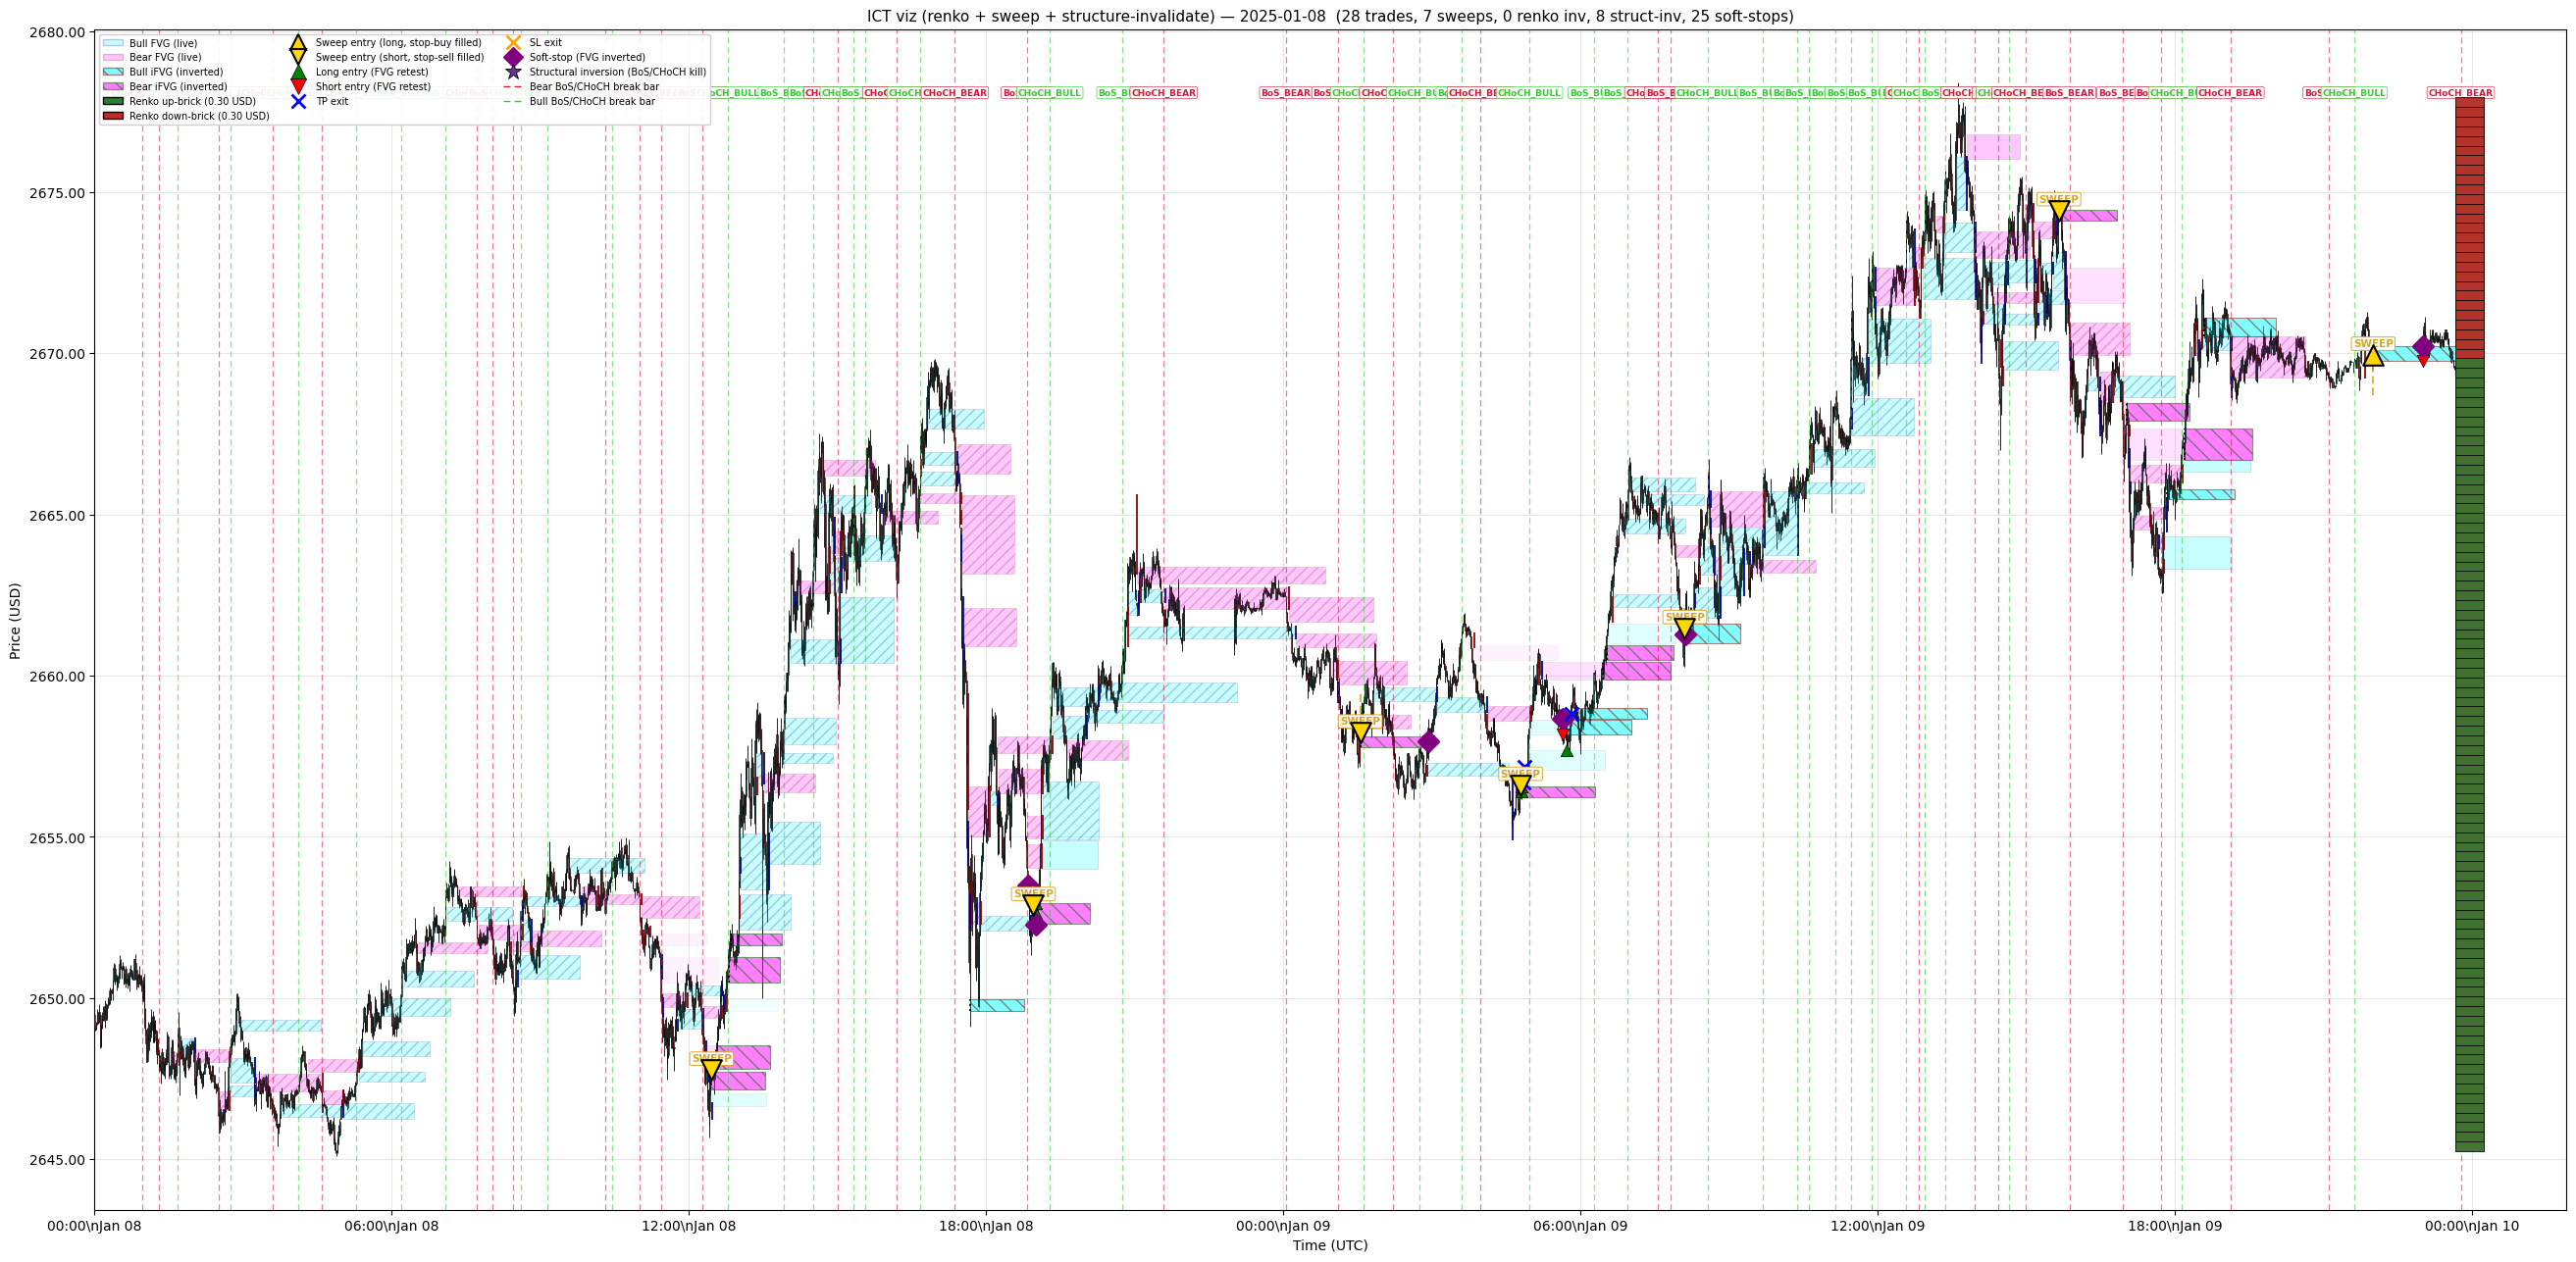

In [5]:
trades = res.trades_df()
# Identify which trades came from sweep signals (single-layer,
# triggered_by='sweep'); they'll get a gold diamond instead of the
# standard arrow. We pull this from the Trade metadata: the bar loop
# stores the triggered_by on each Trade. If the trade isn't a sweep,
# it's an FVG retest with the standard triangle.
sweep_trade_bars = set()
fvg_trade_bars = set()
for _, t in trades.iterrows():
    bar = int(t['entry_bar'])
    if str(t.get('entry_triggered_by', '')) == 'sweep':
        sweep_trade_bars.add(bar)
    else:
        fvg_trade_bars.add(bar)


fig, ax = plt.subplots(figsize=(28, 14))

# Candles (1m)
x_dates = mdates.date2num(df_1m.index.to_pydatetime())
ohl = df_1m[['open', 'high', 'low', 'close']].to_numpy()
opens, highs, lows, closes = ohl[:, 0], ohl[:, 1], ohl[:, 2], ohl[:, 3]
half_w = 0.80 / 2 / (24 * 60)
up_color = '#26a69a'
down_color = '#ef5350'
for x, lo, hi in zip(x_dates, lows, highs):
    ax.vlines(x, lo, hi, color='black', linewidth=0.6, zorder=2)
for x, o, c in zip(x_dates, opens, closes):
    bottom = min(o, c)
    height = max(abs(o - c), 0.001)
    color = up_color if c >= o else down_color
    ax.add_patch(mpatches.Rectangle((x - half_w, bottom), 2 * half_w, height,
                                    facecolor=color, edgecolor='black',
                                    linewidth=0.4, zorder=3))

# FVG zones (same lifecycle logic as nb34)
FVG_FWD_BARS = 3600


def _bar_to_x(bar_idx):
    t = df['time'].iloc[bar_idx]
    return mdates.date2num(t.tz_localize(None) if t.tz is not None else t)


n_drawn = 0
n_superseded_drawn = 0
n_played_out_drawn = 0
n_mitigated_drawn = 0
for z in zones:
    if z.trigger_bar >= len(df):
        continue
    runtime_caps = [z.trigger_bar + FVG_FWD_BARS]
    if z.inverted and z.inverted_bar >= 0 and z.inverted_bar < len(df):
        runtime_caps.append(z.inverted_bar)
    po_bar = getattr(z, 'played_out_bar', -1)
    if po_bar >= 0 and po_bar < len(df):
        runtime_caps.append(po_bar)
    if z.superseded_bar >= 0 and z.superseded_bar < len(df):
        runtime_caps.append(z.superseded_bar)
    right_bar = min(runtime_caps)
    xl = _bar_to_x(z.trigger_bar)
    xr = _bar_to_x(min(len(df) - 1, right_bar))
    if xr <= xl:
        continue
    if z.superseded_bar >= 0:
        opacity = 0.10 if z.mitigated_bar >= 0 else 0.22
        n_mitigated_drawn += 1 if z.mitigated_bar >= 0 else 0
        face = 'cyan' if z.direction == 1 else 'magenta'
        edge = 'darkblue' if z.direction == 1 else 'darkred'
        ax.add_patch(mpatches.Rectangle(
            (xl, z.zone_low), xr - xl, z.zone_high - z.zone_low,
            facecolor=face, edgecolor=edge, alpha=opacity,
            hatch='///', linewidth=0.4, zorder=2,
        ))
        sup_x = _bar_to_x(z.superseded_bar)
        ax.plot([sup_x, sup_x], [z.zone_low, z.zone_high],
                color=edge, linewidth=1.4, linestyle='-', alpha=0.9, zorder=3)
        n_superseded_drawn += 1
    elif po_bar >= 0:
        ax.add_patch(mpatches.Rectangle(
            (xl, z.zone_low), xr - xl, z.zone_high - z.zone_low,
            facecolor='wheat', edgecolor='saddlebrown', alpha=0.10,
            hatch='..', linewidth=0.4, zorder=2,
        ))
        n_played_out_drawn += 1
    else:
        if z.mitigated_bar >= 0 and z.mitigated_depth_pct >= 0.5:
            opacity = 0.05
            n_mitigated_drawn += 1
        elif z.mitigated_bar >= 0:
            opacity = 0.12
            n_mitigated_drawn += 1
        else:
            opacity = 0.22
        face = 'cyan' if z.direction == 1 else 'magenta'
        edge = 'darkblue' if z.direction == 1 else 'darkred'
        ax.add_patch(mpatches.Rectangle(
            (xl, z.zone_low), xr - xl, z.zone_high - z.zone_low,
            facecolor=face, edgecolor=edge, alpha=opacity,
            linewidth=0.4, zorder=2,
        ))
    if (
        z.pierced_bar >= 0
        and z.inverted_bar < 0
        and z.pierced_bar < len(df)
    ):
        probe_x = _bar_to_x(z.pierced_bar)
        ax.plot([probe_x, probe_x], [z.zone_low, z.zone_high],
                color='orange', linewidth=1.0, linestyle='--',
                alpha=0.85, zorder=3)
    n_drawn += 1

# Compute chart y-range upfront so the structure-break overlay can
# place its labels near the top of the chart.
y_min_v, y_max_v = df_1m['low'].min(), df_1m['high'].max()
y_range_v = max(y_max_v - y_min_v, 0.01)

# Structure breaks (added 2026-09-05) — vertical dashed arrows on
# the bar where the BoS/CHoCH fired, with a directional label. Bear
# events are red, bull events are green. These help the user see
# WHICH structure event killed WHICH FVG (zones that were inverted
# structurally have a structural event drawn inside their window).
for be in structure.breaks:
    if be.bar < 0 or be.bar >= len(df):
        continue
    sx = _bar_to_x(be.bar)
    if be.kind == int(StructureEvent.BOS_BEAR) or be.kind == int(StructureEvent.CHOCH_BEAR):
        s_color = 'crimson'
        s_label = f"BoS_BEAR" if be.kind == int(StructureEvent.BOS_BEAR) else f"CHoCH_BEAR"
    elif be.kind == int(StructureEvent.BOS_BULL) or be.kind == int(StructureEvent.CHOCH_BULL):
        s_color = 'limegreen'
        s_label = f"BoS_BULL" if be.kind == int(StructureEvent.BOS_BULL) else f"CHoCH_BULL"
    else:
        continue  # liquidity sweeps etc — skip
    ax.axvline(
        sx, color=s_color, linewidth=0.9, linestyle=(0, (5, 3)),
        alpha=0.55, zorder=4,
    )
    # Tiny label near the top of the chart
    ax.text(
        sx, y_max_v - y_range_v * 0.005, s_label,
        color=s_color, fontsize=6.5, fontweight='bold',
        ha='center', va='top', zorder=5,
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                  edgecolor=s_color, alpha=0.85, linewidth=0.5),
    )

# iFVG rectangles (after inverted_bar)
IFVG_FWD_BARS = 3600
for z in zones:
    if not (z.inverted and z.inverted_bar >= 0 and z.inverted_bar < len(df)):
        continue
    ifxl = _bar_to_x(z.inverted_bar)
    ifxr = _bar_to_x(min(len(df) - 1, z.inverted_bar + IFVG_FWD_BARS))
    if ifxr <= ifxl:
        continue
    face = 'cyan' if z.direction == 1 else 'magenta'
    edge = 'darkred' if z.direction == 1 else 'darkgreen'
    ax.add_patch(mpatches.Rectangle(
        (ifxl, z.zone_low), ifxr - ifxl, z.zone_high - z.zone_low,
        facecolor=face, edgecolor=edge, alpha=0.5,
        hatch='\\\\', linewidth=0.8, zorder=2,
    ))
    inv_x = _bar_to_x(z.inverted_bar)
    # Distinguish structural inversion (BoS/CHoCH flipped the zone,
    # no price-side pierce) from price-side inversion (a 1s close
    # committed past the zone edge). Structural inversions get a
    # purple dotted line (matches the bar-loop soft-stop color
    # scheme where structural events fire earlier); price-side
    # inversions get the standard orange dashed line.
    if z.pierced_bar < 0:
        inv_color = 'rebeccapurple'
        inv_style = ':'
        # Star marker at the structural-inversion bar so the user can
        # see at a glance which inversion came from BoS/CHoCH vs a
        # price-side event.
        ax.scatter(
            [inv_x], [z.zone_high + y_range_v * 0.003],
            marker='*', color='rebeccapurple', s=120, zorder=5,
            edgecolor='black', linewidth=0.6,
        )
    else:
        inv_color = 'black'
        inv_style = ':'
    ax.plot([inv_x, inv_x], [z.zone_low, z.zone_high],
            color=inv_color, linewidth=1.4, linestyle=inv_style, zorder=3)

# Renko brick staircase — drawn on the right edge of the chart, in
# the dead space. Each brick is a small horizontal rectangle with
# the brick's price range. Up-bricks are green; down-bricks are red.
# We size the brick height in chart-space so 1 renko brick ≈ 1/8 of
# the visible y-range.
# NOTE: y_min_v / y_max_v / y_range_v are defined earlier (above
# the structure-breaks overlay) so they're available here.
brick_h = y_range_v * 0.012  # 1.2% of y-range per brick
# The staircase is placed at a fixed x offset from the chart's right
# edge so it doesn't overlap candles. Width: 1% of the chart.
chart_xr = mdates.date2num(df_1m.index[-1])
chart_xl = mdates.date2num(df_1m.index[0])
chart_xrange = chart_xr - chart_xl
staircase_xr = chart_xr + chart_xrange * 0.005
staircase_xl = staircase_xr - chart_xrange * 0.025  # 2.5% of chart width
staircase_w = staircase_xr - staircase_xl
# Anchor the staircase at the renko's last close so the user can
# track the bricks relative to recent price.
# Actually we draw the bricks stacked at a single x position
# (vertical column at chart_xr), so it's a "time-decoupled" staircase
# that the eye reads as the renko state at any moment.
brick_xr = chart_xr + chart_xrange * 0.005
brick_xl = brick_xr - chart_xrange * 0.012
# Draw every brick
for bi in range(renko.n_bricks):
    bo = float(renko.brick_open[bi])
    bc = float(renko.brick_close[bi])
    bd = int(renko.brick_direction[bi])
    # Anchor at the brick's CLOSE — we draw the rectangle ABOVE
    # (down-brick) or BELOW (up-brick) the close so the staircase
    # grows in the brick direction.
    if bd > 0:
        # Up-brick: rectangle [close - brick_size, close]
        rect_lo = bc - (bc - bo)
        rect_hi = bc
        color = '#2e7d32'  # dark green
        edge = 'black'
    else:
        # Down-brick: rectangle [close, close + brick_size]
        rect_lo = bc
        rect_hi = bc + (bo - bc)
        color = '#c62828'  # dark red
        edge = 'black'
    ax.add_patch(mpatches.Rectangle(
        (brick_xl, rect_lo), brick_w := (brick_xr - brick_xl),
        rect_hi - rect_lo,
        facecolor=color, edgecolor=edge, alpha=0.85, linewidth=0.5,
        zorder=7,
    ))

# Sweep stop-order entries — gold diamonds at the fill price +
# dashed connector from the parent FVG zone.
for _, t in trades.iterrows():
    if str(t.get('entry_triggered_by', '')) != 'sweep':
        continue
    ep = float(t.entry_price)
    direction = int(t.direction)
    entry_t = pd.Timestamp(t.entry_time).tz_localize(None)
    entry_x = mdates.date2num(entry_t)
    color = 'gold'
    if direction == 1:
        marker = '^'
    else:
        marker = 'v'
    ax.scatter(
        [entry_x], [ep], marker=marker, color=color, s=220, zorder=7,
        edgecolor='black', linewidth=1.5,
    )
    # Dashed connector from parent FVG zone's nearest edge to the fill.
    # The parent zone is in ``t.fvg_zone`` (not serialised in the
    # DataFrame, so we look it up via the zones list by trigger_bar +
    # direction).
    fvg_zone_obj = t.get('fvg_zone') if hasattr(t, 'get') else None
    # t.get only works on Series — fall back to attribute access.
    if fvg_zone_obj is None and hasattr(t, 'fvg_zone'):
        fvg_zone_obj = t['fvg_zone'] if 'fvg_zone' in t.index else None
    if fvg_zone_obj is None:
        # Re-derive the parent zone by direction+zone proximity.
        for z in zones:
            if z.direction == direction:
                if z.zone_low - 0.30 <= ep <= z.zone_high + 0.30:
                    fvg_zone_obj = z
                    break
    if fvg_zone_obj is not None:
        zl = float(fvg_zone_obj.zone_low)
        zh = float(fvg_zone_obj.zone_high)
        if direction == 1:
            connector_y = zl
        else:
            connector_y = zh
        ax.plot(
            [entry_x, entry_x], [connector_y, ep],
            color='goldenrod', linewidth=1.4, alpha=0.85,
            linestyle=(0, (4, 2)),  # dashed
            solid_capstyle='butt', zorder=6.5,
        )
        # Label
        ax.text(
            entry_x, ep + y_range_v * 0.006, 'SWEEP',
            color='goldenrod', fontsize=7.5, fontweight='bold',
            ha='center', va='bottom', zorder=6.5,
            bbox=dict(boxstyle='round,pad=0.18',
                      facecolor='white', edgecolor='goldenrod',
                      alpha=0.95, linewidth=0.7),
        )

# Trades — entry triangles + exit markers (FVG retest path only;
# sweep trades already drawn above).
for _, t in trades.iterrows():
    if str(t.get('entry_triggered_by', '')) == 'sweep':
        continue  # already drawn
    direction = int(t.direction)
    ep = float(t.entry_price)
    entry_t = pd.Timestamp(t.entry_time).tz_localize(None)
    exit_t = pd.Timestamp(t.exit_time).tz_localize(None)
    if direction == 1:
        ax.scatter(entry_t, ep, marker='^', color='green', s=80,
                   zorder=6, edgecolor='black', linewidth=0.5)
    else:
        ax.scatter(entry_t, ep, marker='v', color='red', s=80,
                   zorder=6, edgecolor='black', linewidth=0.5)
    er = t.exit_reason
    if er == 'tp':
        color = 'blue'
    elif er == 'sl':
        color = 'orange'
    elif er == 'inv':
        color = 'purple'  # soft-stop
    elif er == 'eod':
        color = 'gray'
    else:
        color = 'black'
    marker = 'x' if er != 'inv' else 'D'
    ax.scatter(exit_t, t.exit_price, marker=marker, color=color,
               s=100, zorder=6, linewidths=2)

ax.set_title(
    f'ICT viz (renko + sweep + structure-invalidate) — {VIZ_DATE}  '
    f'({len(trades)} trades, {res.n_sweep_fills} sweeps, '
    f'{res.n_renko_invalidations} renko inv, '
    f'{res.n_structure_invalidations} struct-inv, '
    f'{res.n_soft_stops} soft-stops)',
    fontsize=11,
)
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Time (UTC)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\\n%b %d'))
# Extend xlim right to make room for the renko staircase.
ax.set_xlim(chart_xl, chart_xr + chart_xrange * 0.04)
ax.set_ylim(
    df_1m['low'].min() - y_range_v * 0.05,
    df_1m['high'].max() + y_range_v * 0.05,
)

legend_handles = [
    # FVG zones
    mpatches.Patch(facecolor='cyan', edgecolor='darkblue', alpha=0.22,
                   label='Bull FVG (live)'),
    mpatches.Patch(facecolor='magenta', edgecolor='darkred', alpha=0.22,
                   label='Bear FVG (live)'),
    mpatches.Patch(facecolor='cyan', edgecolor='darkred', alpha=0.5,
                   hatch='\\\\', label='Bull iFVG (inverted)'),
    mpatches.Patch(facecolor='magenta', edgecolor='darkgreen', alpha=0.5,
                   hatch='\\\\', label='Bear iFVG (inverted)'),
    # Renko staircase
    mpatches.Patch(facecolor='#2e7d32', edgecolor='black',
                   label=f'Renko up-brick ({float(p.renko_brick_size_usd):.2f} USD)'),
    mpatches.Patch(facecolor='#c62828', edgecolor='black',
                   label=f'Renko down-brick ({float(p.renko_brick_size_usd):.2f} USD)'),
    # Sweep entries
    plt.Line2D([0], [0], color='gold', marker='^', linestyle='', markersize=12,
               markeredgecolor='black', markeredgewidth=1.5,
               label='Sweep entry (long, stop-buy filled)'),
    plt.Line2D([0], [0], color='gold', marker='v', linestyle='', markersize=12,
               markeredgecolor='black', markeredgewidth=1.5,
               label='Sweep entry (short, stop-sell filled)'),
    # Trade entries & exits
    plt.Line2D([0], [0], color='green', marker='^', linestyle='', markersize=11,
               markeredgecolor='black', markeredgewidth=0.5,
               label='Long entry (FVG retest)'),
    plt.Line2D([0], [0], color='red', marker='v', linestyle='', markersize=11,
               markeredgecolor='black', markeredgewidth=0.5,
               label='Short entry (FVG retest)'),
    plt.Line2D([0], [0], color='blue', marker='x', linestyle='', markersize=10,
               markeredgewidth=2, label='TP exit'),
    plt.Line2D([0], [0], color='orange', marker='x', linestyle='', markersize=10,
               markeredgewidth=2, label='SL exit'),
    plt.Line2D([0], [0], color='purple', marker='D', linestyle='', markersize=10,
               label='Soft-stop (FVG inverted)'),
    # Structure-driven invalidation (added 2026-09-05)
    plt.Line2D([0], [0], color='rebeccapurple', marker='*', linestyle='', markersize=12,
               markeredgecolor='black', markeredgewidth=0.6,
               label='Structural inversion (BoS/CHoCH kill)'),
    plt.Line2D([0], [0], color='crimson', linestyle=(0, (5, 3)), linewidth=1.0,
               label='Bear BoS/CHoCH break bar'),
    plt.Line2D([0], [0], color='limegreen', linestyle=(0, (5, 3)), linewidth=1.0,
               label='Bull BoS/CHoCH break bar'),
]
ax.legend(handles=legend_handles, loc='upper left', ncol=3,
          fontsize=7, framealpha=0.92)
fig.subplots_adjust(top=0.93, bottom=0.07, left=0.05, right=0.95)

# 2026-09-05: render INLINE (no PNG file).
try:
    from IPython.display import display as _ipy_display
    _ipy_display(fig)
except ImportError:
    out = ROOT / 'notebooks' / 'nb36_chart.png'
    fig.savefig(out, dpi=160)
    print(f'Chart saved (no IPython): {out}')
plt.close(fig)


## Inspect the sweep entries + renko invalidations + structure-driven inversions

In [6]:
sweep_trades = trades[trades['entry_triggered_by'] == 'sweep']
print(f'Sweep trades: {len(sweep_trades)}')
if len(sweep_trades) > 0:
    cols = ['entry_time', 'exit_time', 'direction', 'entry_price',
            'exit_price', 'hold_secs', 'exit_reason', 'pnl_usd']
    print(sweep_trades[cols].to_string(index=False))

print()
# How many sweep signals fired vs filled?
print(f'Sweep signals emitted: {res.n_sweep_signals}')
print(f'Sweep fills: {res.n_sweep_fills}')
fill_rate = (res.n_sweep_fills / max(1, res.n_sweep_signals))
print(f'Fill rate: {fill_rate:.1%}')

# Renko invalidations
print()
print(f'Renko-driven invalidations: {res.n_renko_invalidations}')
print(f'Total soft-stops: {res.n_soft_stops}')
if res.n_soft_stops > 0:
    print(f'Soft-stop fraction via renko: '
          f'{(res.n_renko_invalidations / res.n_soft_stops):.1%}')

# Structure-driven invalidations (added 2026-09-05)
print()
print(f'Structure-driven FVG invalidations (from backtest): '
      f'{res.n_structure_invalidations}')
# Note: the ``zones`` list above was re-detected in this cell WITHOUT
# the structural rule, so we can't count structurally-inverted zones
# from it. The authoritative count is ``res.n_structure_invalidations``
# which was produced by the backtest driver (the detector there ran
# with ``fvg_invalidate_on_structure=True``). For the structural
# rule's effect on trade entries, see the comparison cell below.


Sweep trades: 7
               entry_time                 exit_time  direction  entry_price  exit_price  hold_secs exit_reason  pnl_usd
2025-01-08 12:27:24+00:00 2025-01-08 12:27:24+00:00         -1     2647.765    2647.725        0.0         inv    0.040
2025-01-08 18:57:07+00:00 2025-01-08 18:57:07+00:00         -1     2652.875    2652.975        0.0         inv   -0.100
2025-01-09 01:33:03+00:00 2025-01-09 01:33:03+00:00         -1     2658.228    2658.148        0.0         inv    0.080
2025-01-09 04:47:15+00:00 2025-01-09 04:47:15+00:00         -1     2656.605    2656.595        0.0         inv    0.010
2025-01-09 08:06:06+00:00 2025-01-09 08:06:06+00:00         -1     2661.468    2661.548        0.0         inv   -0.080
2025-01-09 15:39:16+00:00 2025-01-09 15:39:16+00:00         -1     2674.434    2674.465        0.0         inv   -0.031
2025-01-09 21:59:58+00:00 2025-01-09 21:59:58+00:00          1     2669.948    2669.744        0.0         inv   -0.204

Sweep signals emitted: 

## Comparison — with vs without structure-driven FVG invalidation

The primary backtest above runs with `fvg_invalidate_on_structure=True`.
This cell runs the SAME config with the structural rule turned OFF so
you can see the EV delta attributable specifically to the BoS/CHoCH
gating. A negative EV/trade delta means the structural rule kills
trades that would have lost money (good); a positive delta means
the structural rule killed trades that would have won (bad).


In [7]:
from dataclasses import replace
p_no_struct = replace(p, fvg_invalidate_on_structure=False)
res_no_struct = run_ict_backtest(df, p_no_struct, strategy_label='viz_no_struct')
s_on = res.summary()
s_off = res_no_struct.summary()
print('--- with fvg_invalidate_on_structure=True (default 30s cap) ---')
for k, v in s_on.items():
    print(f'  {k}: {v}')
print(f'  n_structure_invalidations: {res.n_structure_invalidations}')
print()
print('--- with fvg_invalidate_on_structure=False (legacy) ---')
for k, v in s_off.items():
    print(f'  {k}: {v}')
print(f'  n_structure_invalidations: {res_no_struct.n_structure_invalidations}')
print()
ev_on = float(s_on.get('ev_per_trade', 0.0))
ev_off = float(s_off.get('ev_per_trade', 0.0))
ev_delta = ev_on - ev_off
print(f'EV/trade (struct ON): {ev_on:+.4f} USD')
print(f'EV/trade (struct OFF): {ev_off:+.4f} USD')
print(f'EV/trade delta (struct ON − struct OFF): {ev_delta:+.4f} USD')
print(f'Trade-count delta: {res.n_fills - res_no_struct.n_fills:+d}')
print(f'Soft-stop delta: {res.n_soft_stops - res_no_struct.n_soft_stops:+d}')
if ev_delta > 0:
    print('INTERPRETATION: structural rule is NET-POSITIVE — it kills more losing trades than winning ones.')
elif ev_delta < 0:
    print('INTERPRETATION: structural rule is NET-NEGATIVE — it kills more winning trades than losing ones.')
else:
    print('INTERPRETATION: structural rule has no EV impact on this day.')


--- with fvg_invalidate_on_structure=True (default 30s cap) ---
  n_trades: 28
  pnl_total: -0.8241851851848879
  pnl_per_trade: -0.02943518518517457
  win_rate: 0.21428571428571427
  avg_win: 0.13246913580244127
  avg_loss: -0.07359090909088799
  trades_per_day: 19.452574700073978
  ev_per_trade: -0.029435185185174576
  n_soft_stops: 25
  n_structure_invalidations: 8

--- with fvg_invalidate_on_structure=False (legacy) ---
  n_trades: 42
  pnl_total: -0.8600185185183971
  pnl_per_trade: -0.02047663139329517
  win_rate: 0.21428571428571427
  avg_win: 0.16820164609048838
  avg_loss: -0.07193434343432706
  trades_per_day: 29.27679349404589
  ev_per_trade: -0.020476631393295183
  n_soft_stops: 36
  n_structure_invalidations: 0

EV/trade (struct ON): -0.0294 USD
EV/trade (struct OFF): -0.0205 USD
EV/trade delta (struct ON − struct OFF): -0.0090 USD
Trade-count delta: -14
Soft-stop delta: -11
INTERPRETATION: structural rule is NET-NEGATIVE — it kills more winning trades than losing ones.


## Notes & next steps

What this notebook gives you:

1. **A visual side-by-side of the renko brick staircase and the
   candle chart.** Each brick is colored by direction (green = up,
   red = down) and stacked at the chart's right edge so the eye
   can read the renko state at any moment. Multi-brick streaks on
   the wrong side of a zone edge are visually unmistakable.

2. **A clear visual of the sweep trade lifecycle.** Each filled
   sweep gets a gold diamond at the fill bar, with a dashed
   goldenrod connector to the parent FVG zone that sourced it.
   The `SWEEP` label makes it obvious which trades came from the
   sweep source vs the regular FVG retest path.

3. **A clear visual of the structure-driven FVG invalidation
   lifecycle.** Each BoS/CHoCH event is drawn as a labeled
   vertical dashed line at the break bar (crimson for bear
   events, limegreen for bull events). Zones that were
   structurally invalidated (killed by a BoS/CHoCH in the opposing
   direction, with no price-side pierce) get a purple star
   marker at the inversion bar — distinct from the standard
   black dotted line used for price-side inversions.

4. **Backtest diagnostics** in the inspection cell — sweep
   fill rate, renko invalidation count, structure-invalidation
   count, and the fraction of soft-stops driven by renko vs the
   1s-based rules.

5. **A direct EV/trade comparison** with the structural rule
   on vs off. The comparison cell shows whether the BoS/CHoCH
   gating is net-positive or net-negative on this dataset.

What's still TODO before this becomes a strategy-level change:

* **Tune `renko_brick_size_usd`** to the regime. On a 1s XAUUSD
  feed, 0.20-0.50 USD is the sensible range; the bigger the
  brick, the fewer bricks form (and the more conservative the
  renko rule is).
* **Tune `fvg_sweep_distance_usd`** — the stop-order distance past
  the zone edge. Too close = triggered by noise; too far = rarely
  fills.
* **Tune `fvg_structure_invalidation_age_secs`** — the wall-clock
  age cap on zones that can be structurally invalidated. Default
  `0` = unlimited age, which means ANY still-live bull FVG is
  killed by the first bear BoS/CHoCH. That's aggressive; a tighter
  cap (e.g. 1800s = 30 min) lets older zones ride out a single
  structure event without dying.
* **Add an EV-by-tier breakdown** — does the structural rule
  kill A-tier (top-of-day) FVGs more often than C-tier? If A-tier
  zones are being killed at a high rate, the rule may be
  over-aggressive on the structurally strongest levels.
* **Promote `fvg_sweep_atr_mult` to a tiered default** — A-tier
  sweeps (top-of-day FVGs) deserve wider ATR-based SLs because
  the FVG is structurally stronger.
